In [92]:
import matplotlib.pyplot as plt
from electro.dsp import modulations as mod
from electro.dsp import signals as sig
import numpy as np

# Example Analog Modulations
---

## AM

In [93]:
# Adquisition
fs = 10e6       # sampling freq
N = 10000       # cant samples

# Carrier
ac = 2
fc = 100e3      # Carrier freq


# Message
fm = 1e3        # Message freq
m = 0.5
vi = m * ac

t, message = sig.sin(vi, ff=fm, nn=N, fs=fs)
# message = m * np.sin(2*np.pi*t)
# t = np.arange(0, N/fs, 1/fs)

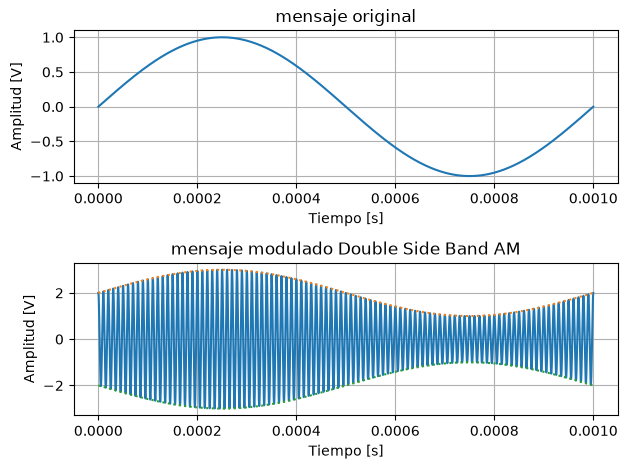

In [94]:
t, bb = mod.DSB(message, ac=ac,  N=N,  fs=fs)
modulated_message = mod.up_carrier(bb, t, fc)

plt.subplot(2,1,1)
plt.plot(t, message)
plt.title("mensaje original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, modulated_message)
plt.title("mensaje modulado Double Side Band AM")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.plot(t, message + ac, linestyle=':')
plt.plot(t, -(message + ac), linestyle=':')

plt.tight_layout()
plt.show()

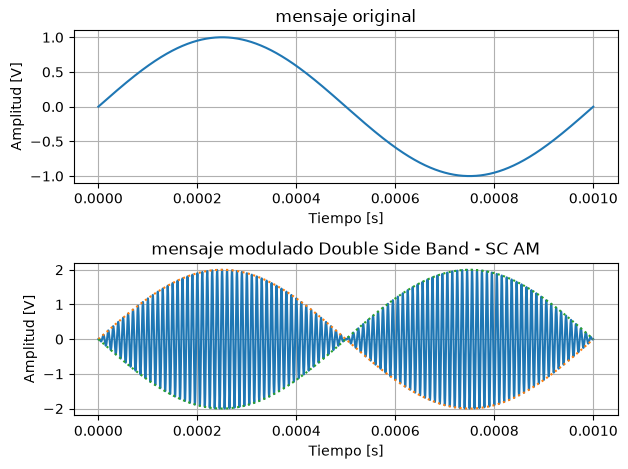

In [95]:
t, bb = mod.DSB_SC(message, ac=ac,  N=N,  fs=fs)
modulated_message = mod.up_carrier(bb, t, fc)

plt.subplot(2,1,1)
plt.plot(t, message)
plt.title("mensaje original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, modulated_message)
plt.title("mensaje modulado Double Side Band - SC AM")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.plot(t, ac*message, linestyle=':')
plt.plot(t, -ac*message, linestyle=':')

plt.tight_layout()
plt.show()


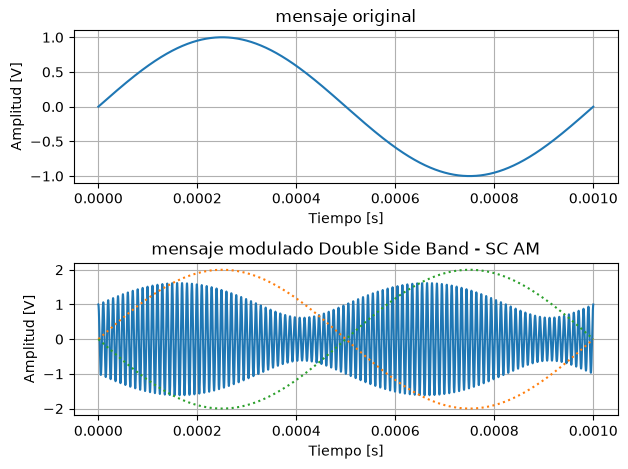

In [96]:
t, bb = mod.SSB(message, ac=ac,  N=N,  fs=fs)
modulated_message = mod.up_carrier(bb, t, fc)

plt.subplot(2,1,1)
plt.plot(t, message)
plt.title("mensaje original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, modulated_message)
plt.title("mensaje modulado Double Side Band - SC AM")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.plot(t, ac*message, linestyle=':')
plt.plot(t, -ac*message, linestyle=':')

plt.tight_layout()
plt.show()


## PM

In [97]:
# Adquisition
fs = 10e6       # sampling freq
N = 10000       # cant samples

# Carrier
ac = 2
fc = 10e3      # Carrier freq


# Message
fm = 1e3        # Message freq
vi = 1

# modulation index
kp = 50

t, message = sig.sin(vi, ff=fm, nn=N, fs=fs)
# message = m * np.sin(2*np.pi*t)
# t = np.arange(0, N/fs, 1/fs)

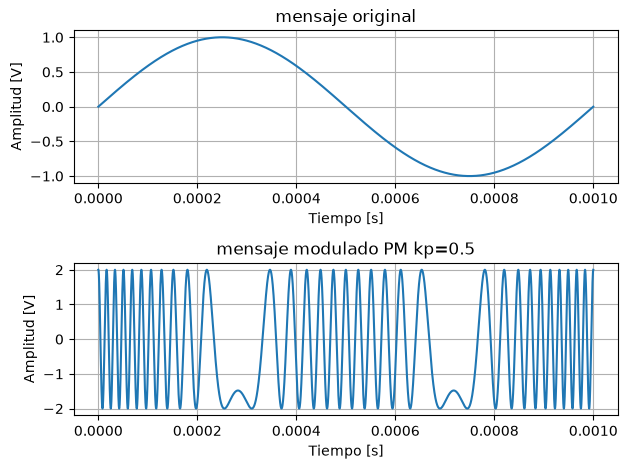

In [98]:
t, bb = mod.PM(message, ac=ac, kp=kp, N=N, fs=fs)
modulated_message = mod.up_carrier(bb, t, fc=fc)

plt.subplot(2,1,1)
plt.plot(t, message)
plt.title("mensaje original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, modulated_message)
plt.title(f"mensaje modulado PM kp={m}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.tight_layout()
plt.show()


## FM

In [99]:
# Adquisition
fs = 10e6       # sampling freq
N = 10000       # cant samples

# Carrier
ac = 1
fc = 50e3      # Carrier freq


# Message
fm = 1e3        # Message freq
vi = 1

# modulation index
kf = 25e3

t, message = sig.sin(vi, ff=fm, nn=N, fs=fs)
# message = m * np.sin(2*np.pi*t)
# t = np.arange(0, N/fs, 1/fs)

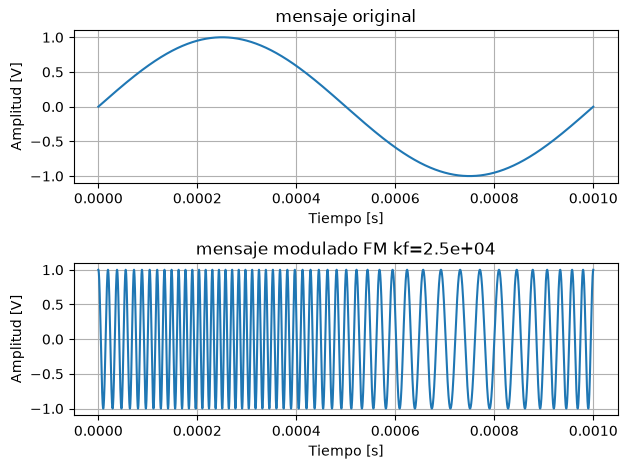

In [100]:
t, bb = mod.FM(message, ac=ac, kf=kf, N=N, fs=fs)
modulated_message = mod.up_carrier(bb, t, fc=fc)

plt.subplot(2,1,1)
plt.plot(t, message)
plt.title("mensaje original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, modulated_message)
plt.title(f"mensaje modulado FM kf={kf:.3g}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.tight_layout()
plt.show()

# Example Digital Modulations
---

In [101]:
# Comm. velocity
R = 1e3
samples_per_bit = 25
Tb = 1/R

fs = int(R * samples_per_bit)   # sample freq

# message
bits = '110010110011'
t, message = mod.polar_nrz(bits, tb=Tb, fs=fs)

# carrier
fc = 10e3

## ASK

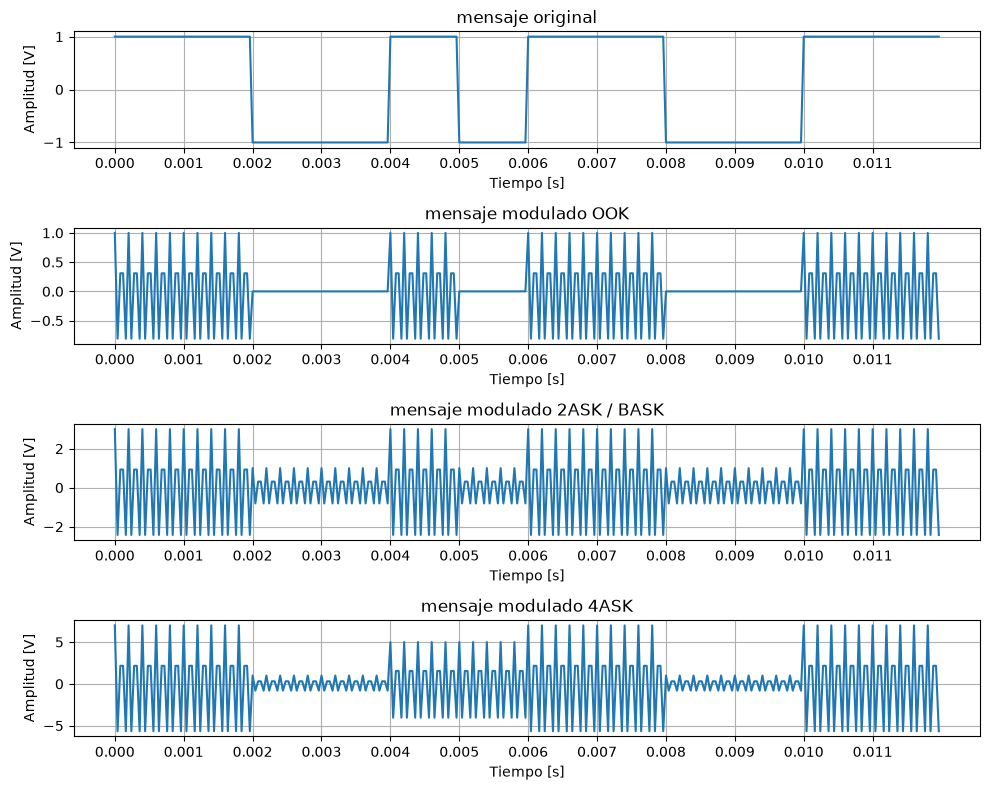

In [102]:
# BASK
t, bb = mod.ook(bits, Tb, fs)
modulated_message1 = mod.up_carrier(bb, t, fc)

# BASK
M = 2
t, bb = mod.m_ask(bits, M, Tb, fs)
modulated_message2 = mod.up_carrier(bb, t, fc)

# 4ASK
M = 4
t, bb = mod.m_ask(bits, M, Tb, fs)
modulated_message3 = mod.up_carrier(bb, t, fc)

plt.figure(figsize=(10,8))
plt.subplot(4,1,1)
plt.plot(t, message)
plt.title("mensaje original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.subplot(4,1,2)
plt.plot(t, modulated_message1)
plt.title(f"mensaje modulado OOK")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.subplot(4,1,3)
plt.plot(t, modulated_message2)
plt.title(f"mensaje modulado 2ASK / BASK")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.subplot(4,1,4)
plt.plot(t, modulated_message3)
plt.title(f"mensaje modulado 4ASK")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.tight_layout()
plt.show()


## PSK 

In [103]:
# Comm. velocity
R = 1e3
samples_per_bit = 25
Tb = 1/R

fs = int(R * samples_per_bit)   # sample freq

# message
bits = '110010110011'
t, message = mod.polar_nrz(bits, tb=Tb, fs=fs)

# carrier
fc = 10e3

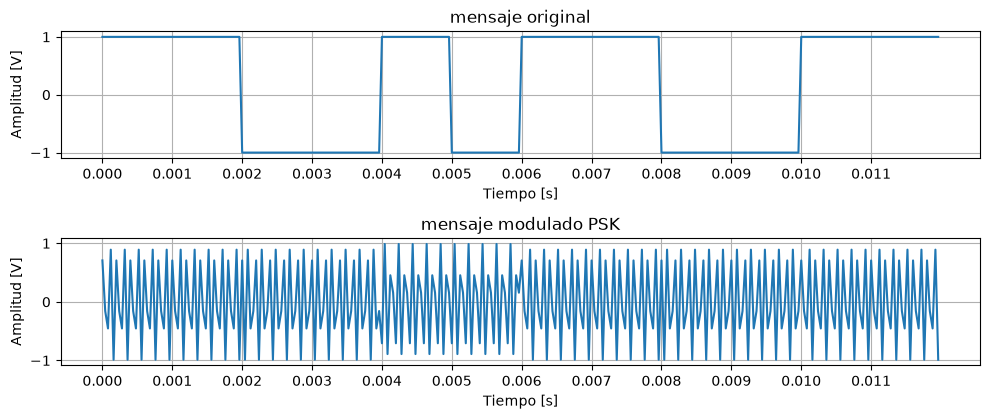

In [104]:
# 4PSK
M = 4
t, bb = mod.m_psk(bits, M, Tb, fs)
modulated_message = mod.up_carrier(bb, t, fc)

plt.figure(figsize=(10,8))
plt.subplot(4,1,1)
plt.plot(t, message)
plt.title("mensaje original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.subplot(4,1,2)
plt.plot(t, modulated_message)
plt.title(f"mensaje modulado PSK")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.tight_layout()
plt.show()


## FSK

In [105]:
# Comm. velocity
R = 1e3
samples_per_bit = 25
Tb = 1/R

fs = int(R * samples_per_bit)   # sample freq

# message
bits = '110010110011'
t, message = mod.polar_nrz(bits, tb=Tb, fs=fs)

# carrier
fc = 10e3

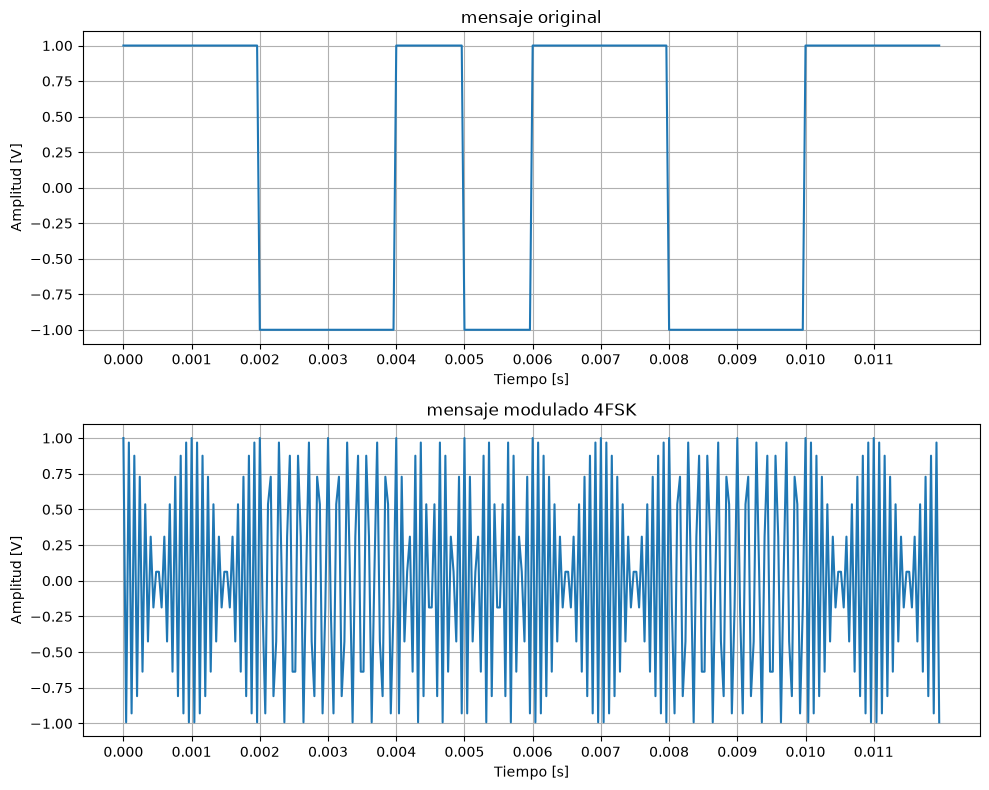

In [106]:
# 4FSK
M = 4
h = 2
t, bb = mod.m_fsk(bits, M, tb=Tb, fs=fs, h=h)
modulated_message = mod.up_carrier(bb, t, fc)

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(t, message)
plt.title("mensaje original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, modulated_message)
plt.title(f"mensaje modulado 4FSK")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.tight_layout()
plt.show()


## QAM

In [107]:
# Comm. velocity
R = 1e3
samples_per_bit = 25
Tb = 1/R

fs = int(R * samples_per_bit)   # sample freq

# message
bits = [1,1,0,0,
		1,0,1,0,
		0,0,1,1,
		1,1,1,0]
t, message = mod.polar_nrz(bits, tb=Tb, fs=fs)

# carrier
fc = 10e3



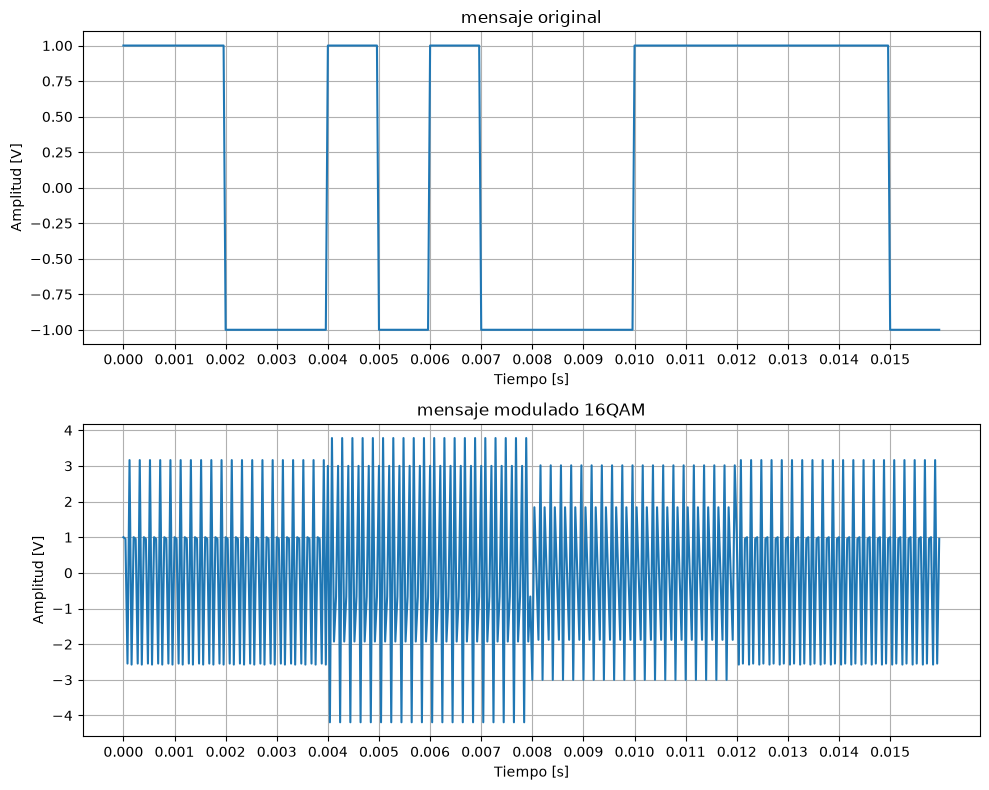

In [108]:
# 16QAM
M = 16
t, bb = mod.m_qam(bits, M, Tb, fs)
modulated_message = mod.up_carrier(bb, t, fc)

plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
plt.plot(t, message)
plt.title("mensaje original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.subplot(2,1,2)
plt.plot(t, modulated_message)
plt.title(f"mensaje modulado 16QAM")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.xticks(np.arange(0, len(bits)*Tb, Tb))
plt.grid()

plt.tight_layout()
plt.show()


# Example Line Coding
---

In [109]:
msg = [1,1,0,0,1,1,0,1,1,1,1,1]
Tb = 1
Fs = 200/Tb

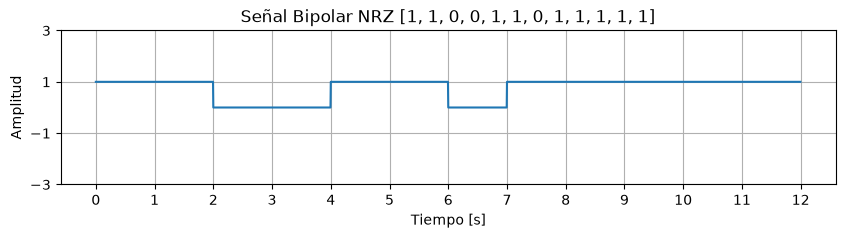

In [110]:
t, signal_U_NRZ = mod.unipolar_nrz(msg, Tb, Fs)

plt.figure(figsize=(10,2))
plt.plot(t, signal_U_NRZ)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal Bipolar NRZ {msg}")
plt.xticks(range(0,13))
plt.yticks([0,0.5,1])
plt.yticks([-3, -1, 1, 3])
plt.grid(True)
plt.show()

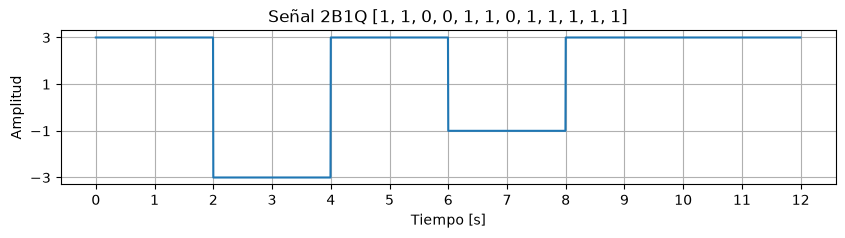

In [111]:
t, signal_2B1Q = mod.twoB1Q(msg, Tb, Fs)

plt.figure(figsize=(10,2))
plt.plot(t, signal_2B1Q)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal 2B1Q {msg}")
plt.xticks(range(0,13))
plt.yticks([0,0.5,1])
plt.yticks([-3, -1, 1, 3])
plt.grid(True)
plt.show()

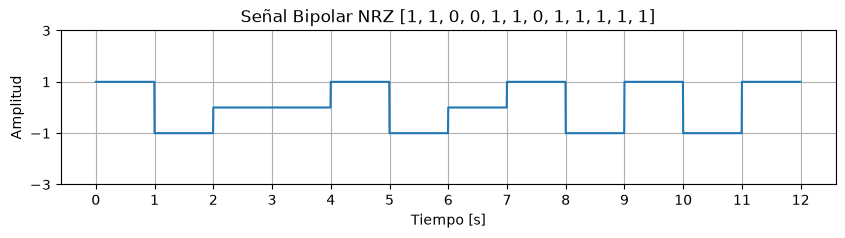

In [112]:
t, signal_B_NRZ = mod.bipolar_nrz(msg, Tb, Fs)

plt.figure(figsize=(10,2))
plt.plot(t, signal_B_NRZ)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal Bipolar NRZ {msg}")
plt.xticks(range(0,13))
plt.yticks([0,0.5,1])
plt.yticks([-3, -1, 1, 3])
plt.grid(True)
plt.show()

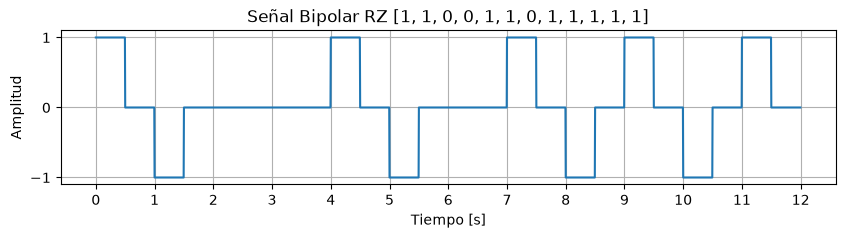

In [113]:
t, signal_B_RZ = mod.bipolar_rz(msg, Tb, Fs)

plt.figure(figsize=(10,2))
plt.plot(t, signal_B_RZ)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal Bipolar RZ {msg}")
plt.xticks(range(0,13))
plt.yticks([0,0.5,1])
plt.yticks([-1, 0, 1])
plt.grid(True)
plt.show()

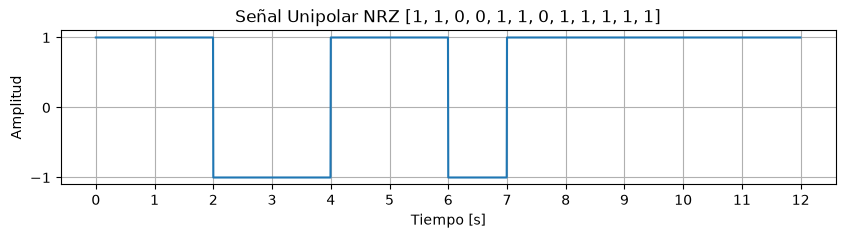

In [114]:
t, signal_P_NRZ = mod.polar_nrz(msg, Tb, Fs)

plt.figure(figsize=(10,2))
plt.plot(t, signal_P_NRZ)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal Unipolar NRZ {msg}")
plt.xticks(range(0,13))
plt.yticks([0,0.5,1])
plt.yticks([ -1, 0, 1])
plt.grid(True)
plt.show()

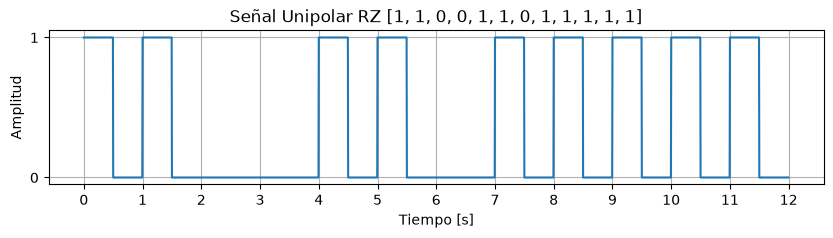

In [115]:
t, signal_U_RZ = mod.unipolar_rz(msg, Tb, Fs)

plt.figure(figsize=(10,2))
plt.plot(t, signal_U_RZ)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal Unipolar RZ {msg}")
plt.xticks(range(0,13))
plt.yticks([0,0.5,1])
plt.yticks([ 0, 1])
plt.grid(True)
plt.show()

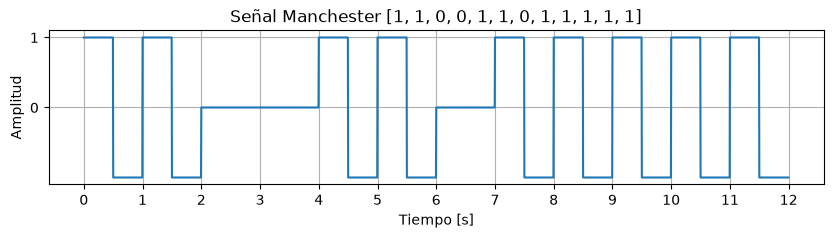

In [116]:
t, signal_manch = mod.manchester(msg, Tb, Fs)

plt.figure(figsize=(10,2))
plt.plot(t, signal_manch)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal Manchester {msg}")
plt.xticks(range(0,13))
plt.yticks([0,0.5,1])
plt.yticks([ 0, 1])
plt.grid(True)
plt.show()

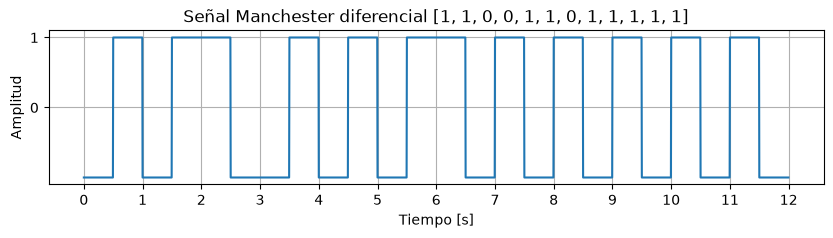

In [117]:
t, signal_diff_manch = mod.differential_manchester(msg, Tb, Fs)

plt.figure(figsize=(10,2))
plt.plot(t, signal_diff_manch)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Señal Manchester diferencial {msg}")
plt.xticks(range(0,13))
plt.yticks([0,0.5,1])
plt.yticks([ 0, 1])
plt.grid(True)
plt.show()

## Comparación Final

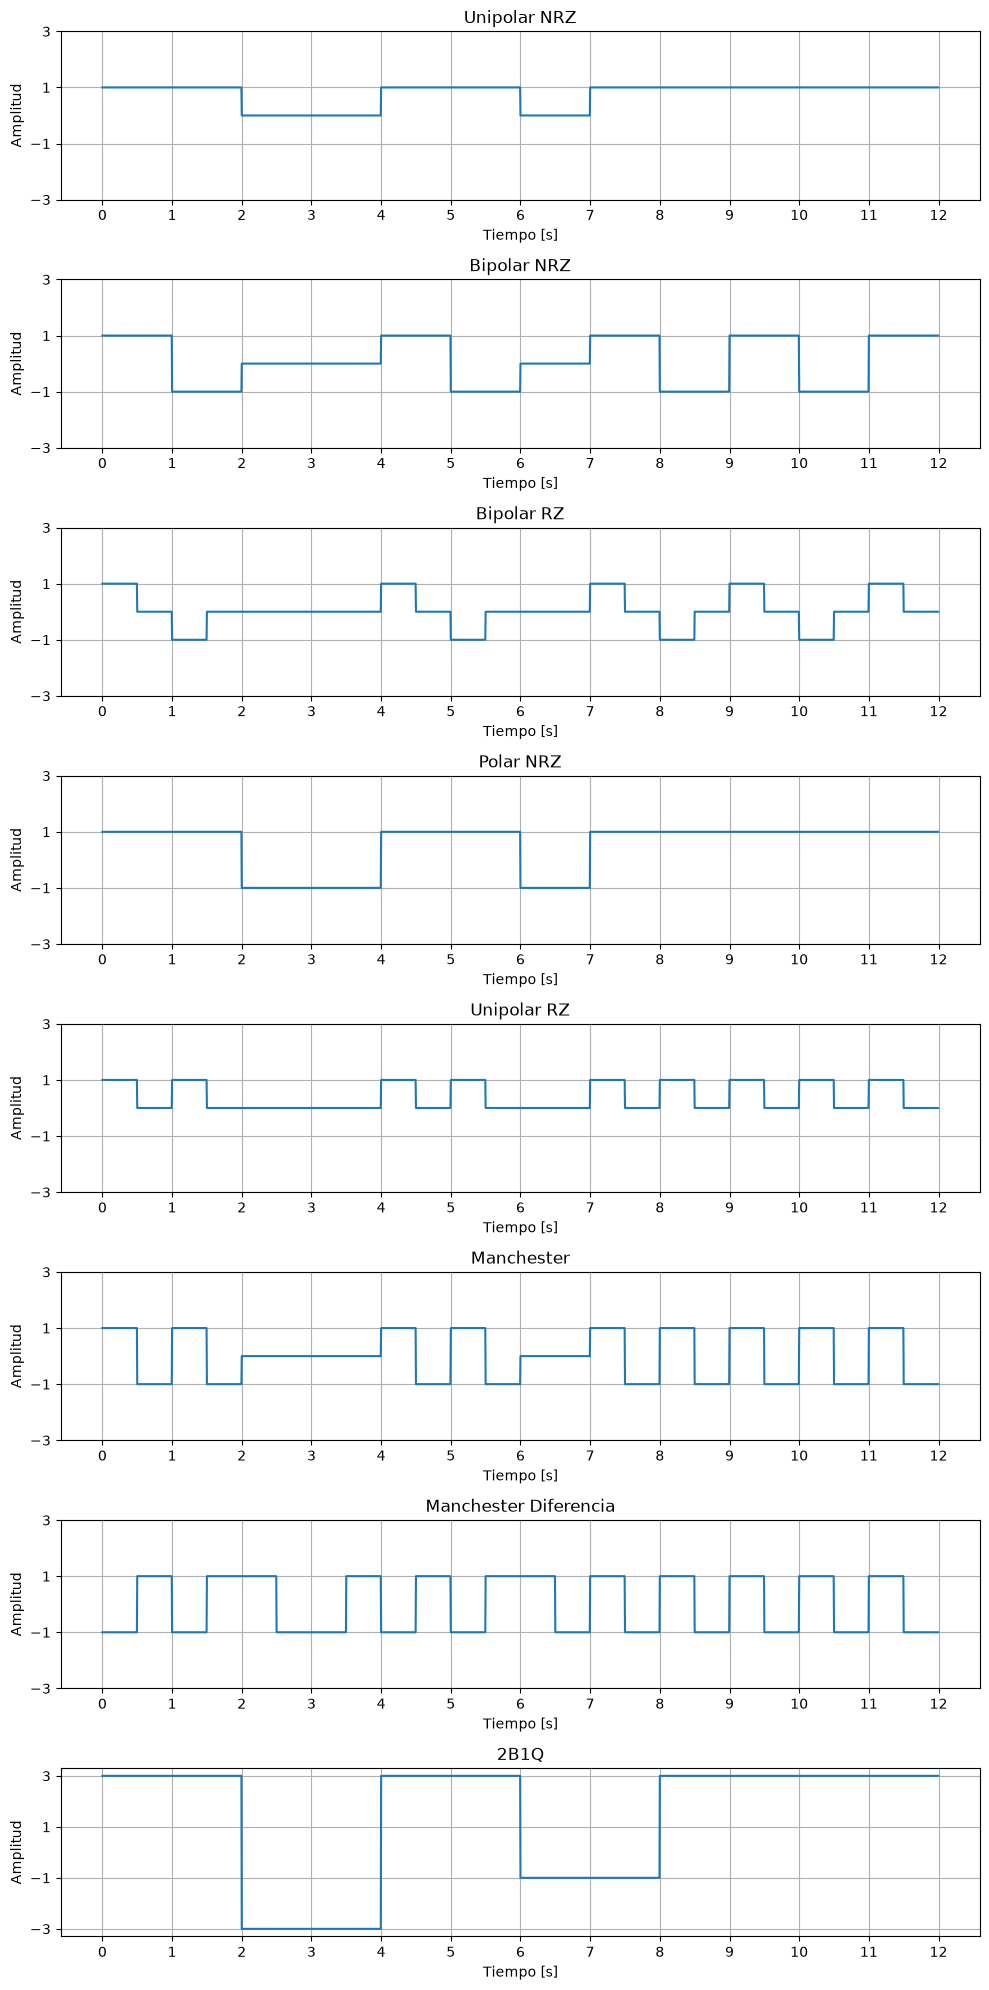

In [118]:
signals = [signal_U_NRZ, signal_B_NRZ, signal_B_RZ, signal_P_NRZ, signal_U_RZ, signal_manch, signal_diff_manch, signal_2B1Q,]
names = ['Unipolar NRZ', 'Bipolar NRZ', 'Bipolar RZ', 'Polar NRZ', 'Unipolar RZ', 'Manchester', 'Manchester Diferencia', '2B1Q']

plt.figure(figsize=(10,20))
for i, (sig, name) in enumerate(zip(signals, names), start=1):
    plt.subplot(len(signals), 1, i)
    plt.plot(t, sig)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.title(name)
    plt.xticks(range(0,13))
    plt.yticks([0,0.5,1])
    plt.yticks([-3, -1, 1, 3])
    plt.grid(True)
plt.tight_layout()
plt.show()